In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def time_axis(fs, duration):
    return np.arange(0, duration, 1/fs)
def generate_sine(f, t, a, p):
    return a*np.sin(2*np.pi*f*t + p)

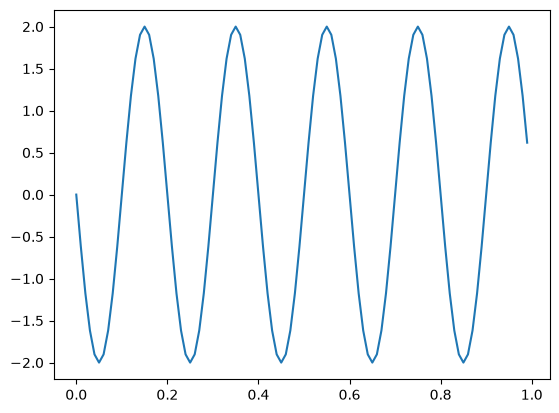

In [3]:
fs = 100
duration = 1
t = time_axis(fs, duration)
x = generate_sine(5, t, 2, np.pi)
plt.plot(t, x)

C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


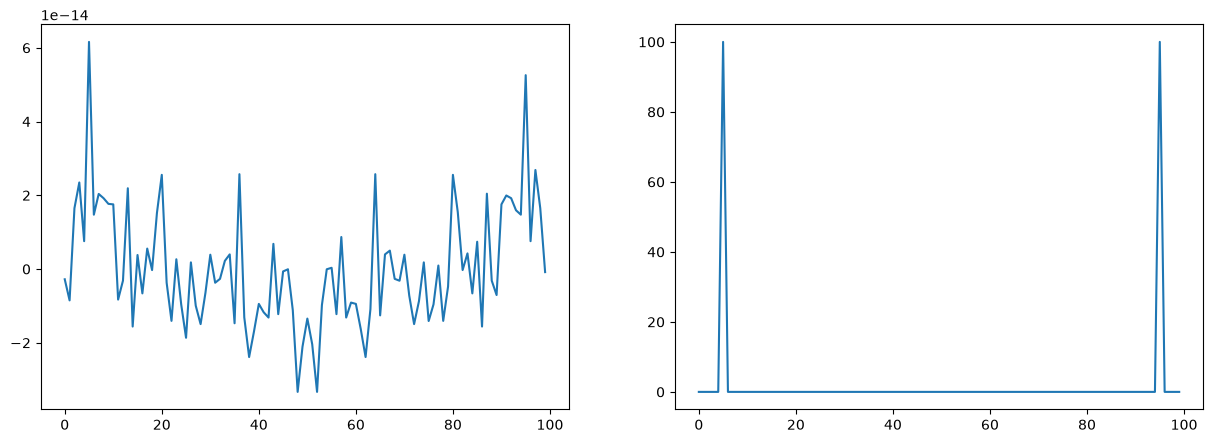

In [4]:
# change the signal to complex form
X = np.fft.fft(x)
# print(X)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(X)

# magnitude = amplitude

amp = np.abs(X)

plt.subplot(1, 2, 2)
plt.plot(amp)
# plt.plot(amp[:len(amp)//2])

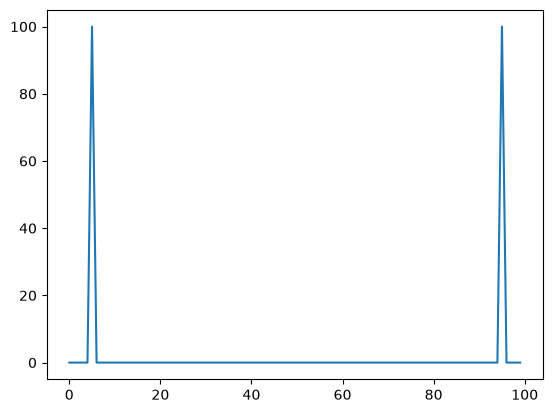

In [5]:
N = len(X)
freqs = np.arange(N) * fs/N
plt.plot(freqs, amp)

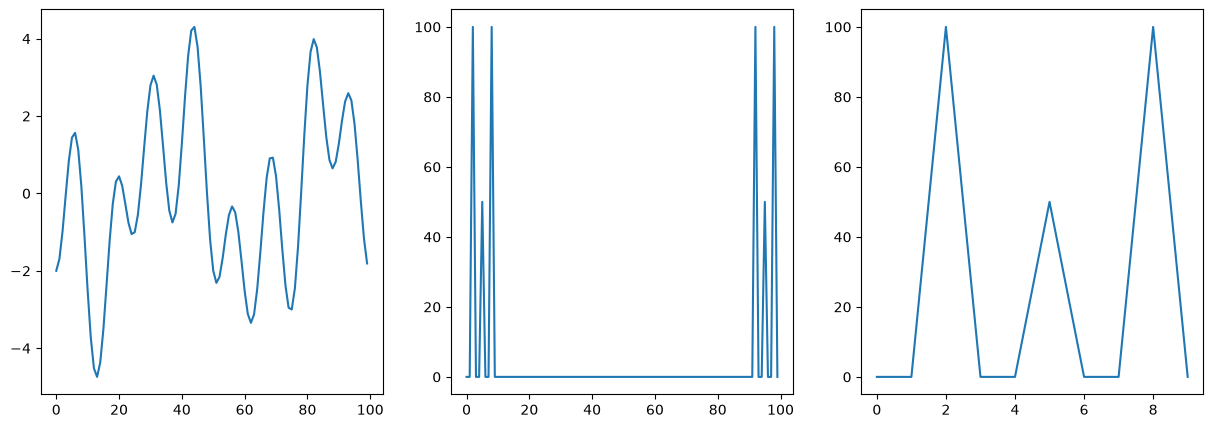

In [6]:
fs = 100
duration = 1
t = time_axis(fs, duration)

# create a signal from 3 different frequency

x = generate_sine(2, t, 2, np.pi) + generate_sine(5, t, 1, 0) + generate_sine(8, t, 2, -np.pi/2)

X = np.fft.fft(x)
amp = np.abs(X)
N = len(X)
freq = np.arange(N) * fs/N

plt.figure(figsize = (15, 5))
plt.subplot(1, 3, 1)
plt.plot(x)
plt.subplot(1, 3, 2)
plt.plot(freq, amp)
plt.subplot(1, 3, 3)
plt.plot(freq[:10], amp[:10])



+ try finding how many frequency is using to create this signals

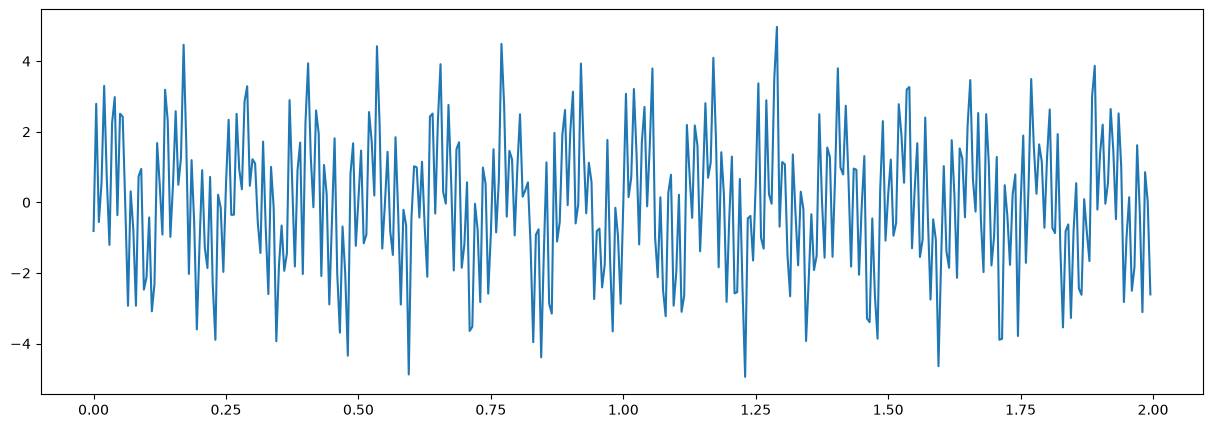

In [7]:
# 1. Setup the time axis
fs = 200          # Sampling frequency: 200 Hz
duration = 2      # Duration: 2 seconds
t = time_axis(fs, duration)

# 2. Generate the mystery signal (frequencies are hidden in the math!)
y_mystery = 1.5 * np.sin(50.26548 * t) + 0.8 * np.sin(157.07963 * t) + 2.0 * np.sin(376.99111 * t)

# 3. Add a little bit of Gaussian noise for realism
np.random.seed(55)
y_mystery += np.random.normal(0, 0.5, len(t))
plt.figure(figsize=(15, 5))
plt.plot(t, y_mystery)

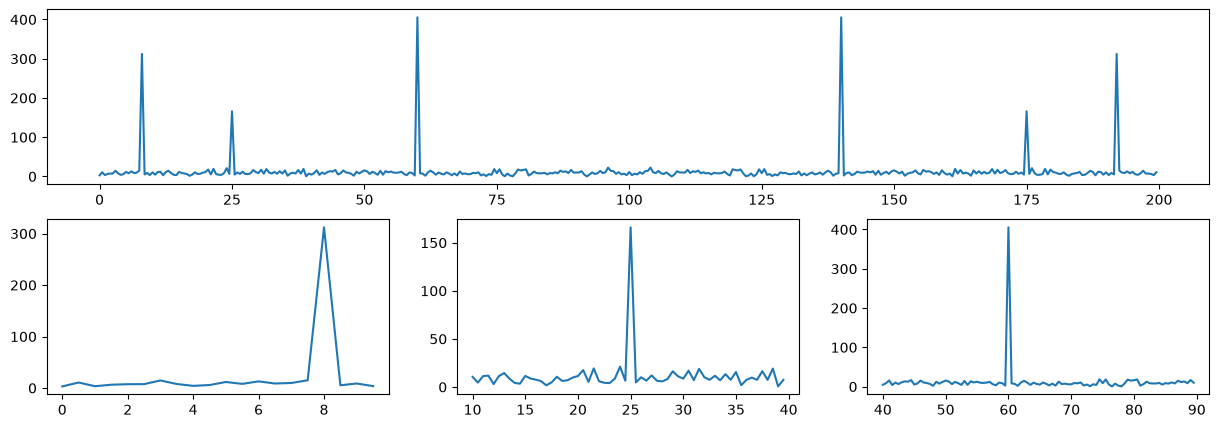

In [26]:
Y = np.fft.fft(y_mystery)

mag = np.abs(Y)
N = len(Y)
freq = np.arange(N) * fs/N

plt.figure(figsize=(15, 5))

plt.subplot(2, 1, 1)
plt.plot(freq, mag)

plt.subplot(2, 3, 4)
plt.plot(freq[:20], mag[:20])

plt.subplot(2, 3, 5)
plt.plot(freq[20:80], mag[20:80])

plt.subplot(2, 3, 6)
plt.plot(freq[80:180], mag[80:180])



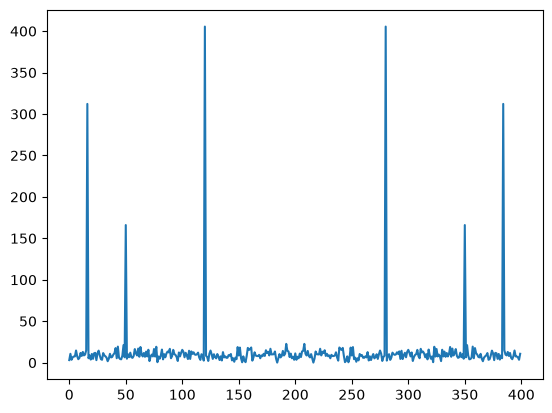

In [27]:
# this graph when we don't find the frequency bin, it will show the index of the mag, which is the bins number but not the actual frequency value

plt.plot(mag) #value x-axis 0 to 400d

In [12]:
# plt.plot(Y)

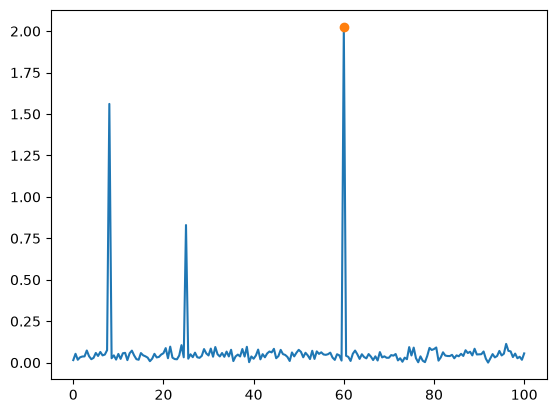

In [49]:
N = len(Y)
mag = 2*np.abs(Y[:N//2 + 1]) / N
freq = np.arange(len(mag)) * fs/N

plt.plot(freq, mag)
peak_idx = np.argmax(mag)   # restrict to first half to avoid mirror
# print(freq[peak_idx], mag[peak_idx])
plt.plot(freq[peak_idx], mag[peak_idx], "o")


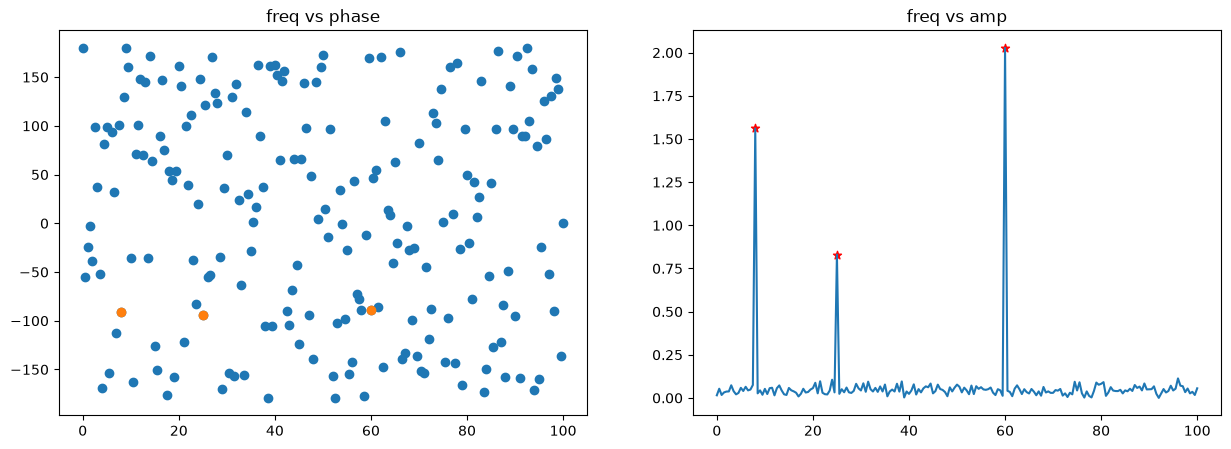

In [47]:
important = mag > 0.8
phase = np.angle(Y[:N//2 + 1], deg = True)



plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title("freq vs phase")
plt.scatter(freq, phase)
plt.scatter(freq[important], phase[important])

plt.subplot(1, 2, 2)
plt.title("freq vs amp")
plt.plot(freq, mag)
plt.scatter(freq[important], mag[important], marker = "*", color = "red")

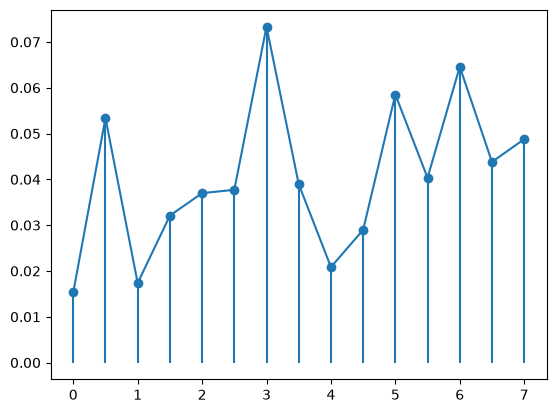

In [68]:
# plt.subplot(1, 2, 1)
plt.plot(freq[:15], mag[:15], 'o-')
plt.vlines(freq[:15], 0, mag[:15])

# mag = 2*np.abs(Y[:N//2 + 1]) / N
